# Knee Osteoarthritis Severity Classification – Deep Learning Pipeline

**Task**: Multi-class classification of knee X-ray images into KL (Kellgren-Lawrence) grades 0–4.

| Grade | Label | Description |
|-------|-------|-------------|
| 0 | Healthy | No signs of osteoarthritis |
| 1 | Doubtful | Doubtful joint narrowing, possible osteophytic lipping |
| 2 | Minimal | Definite osteophytes, possible joint space narrowing |
| 3 | Moderate | Multiple osteophytes, definite joint space narrowing, mild sclerosis |
| 4 | Severe | Large osteophytes, significant joint narrowing, severe sclerosis |

**Pipeline**:
1. Data exploration & visualisation
2. Augmentation strategy & DataLoaders
3. Transfer learning with EfficientNet-B4 (upgraded from B3 to address underfitting)
4. Class-weighted loss to handle imbalance
5. Training with early stopping & LR scheduling
6. Evaluation: confusion matrix, classification report, per-class metrics


## 1. Install Dependencies

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet
# If no GPU / CUDA not available, use CPU-only build:
# %pip install torch torchvision torchaudio --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 3. Configuration

In [ ]:
# --- Paths ---
DATA_DIR = Path('data')          # relative to this notebook
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# --- Hyperparameters ---
NUM_CLASSES   = 5
IMG_SIZE      = 380          # EfficientNet-B4 native resolution (compound scaling: wider/deeper than B3)
BATCH_SIZE    = 16           # Reduced from 32 — B4 uses ~60% more GPU memory at 380px
NUM_EPOCHS    = 50
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
WARMUP_EPOCHS = 5            # LR warmup epochs for Phase 2 — prevents destabilisation after unfreezing
LABEL_SMOOTH  = 0.1          # label smoothing — helps with ordinal KL-grade uncertainty


CLASS_NAMES   = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
GRADE_LABELS  = {0: 'Healthy', 1: 'Doubtful', 2: 'Minimal', 3: 'Moderate', 4: 'Severe'}


## 4. Data Exploration

In [4]:
# Count images per class per split
splits = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}
counts = {}
for split, path in splits.items():
    counts[split] = [len(list((path / str(g)).glob('*.*'))) for g in range(NUM_CLASSES)]

print(f"{'Grade':<8} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-' * 36)
for g in range(NUM_CLASSES):
    label = GRADE_LABELS[g]
    print(f"{g} ({label:<8}) {counts['train'][g]:>8} {counts['val'][g]:>8} {counts['test'][g]:>8}")
print('-' * 36)
print(f"{'Total':<8} {sum(counts['train']):>8} {sum(counts['val']):>8} {sum(counts['test']):>8}")

Grade       Train      Val     Test
------------------------------------
0 (Healthy )     2286      328      639
1 (Doubtful)     1046      153      296
2 (Minimal )     1516      212      447
3 (Moderate)      757      106      223
4 (Severe  )      173       27       51
------------------------------------
Total        5778      826     1656


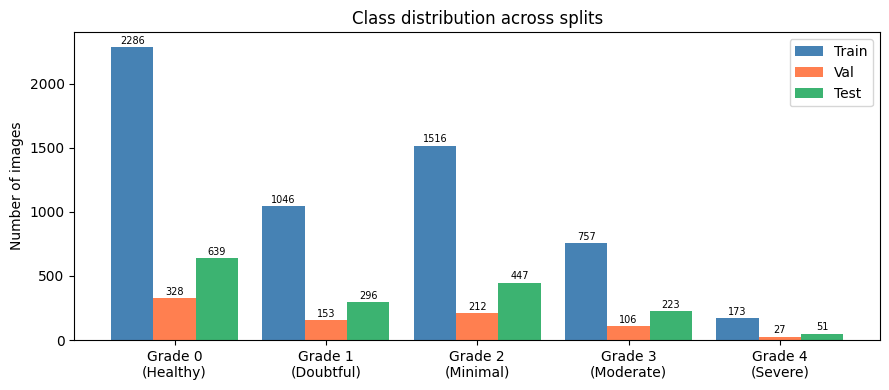

In [5]:
# Class distribution bar chart
x = np.arange(NUM_CLASSES)
width = 0.28
fig, ax = plt.subplots(figsize=(9, 4))
bars = [
    ax.bar(x - width, counts['train'], width, label='Train', color='steelblue'),
    ax.bar(x,         counts['val'],   width, label='Val',   color='coral'),
    ax.bar(x + width, counts['test'],  width, label='Test',  color='mediumseagreen'),
]
ax.set_xticks(x)
ax.set_xticklabels([f'Grade {g}\n({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)])
ax.set_ylabel('Number of images')
ax.set_title('Class distribution across splits')
ax.legend()
for bar_group in bars:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

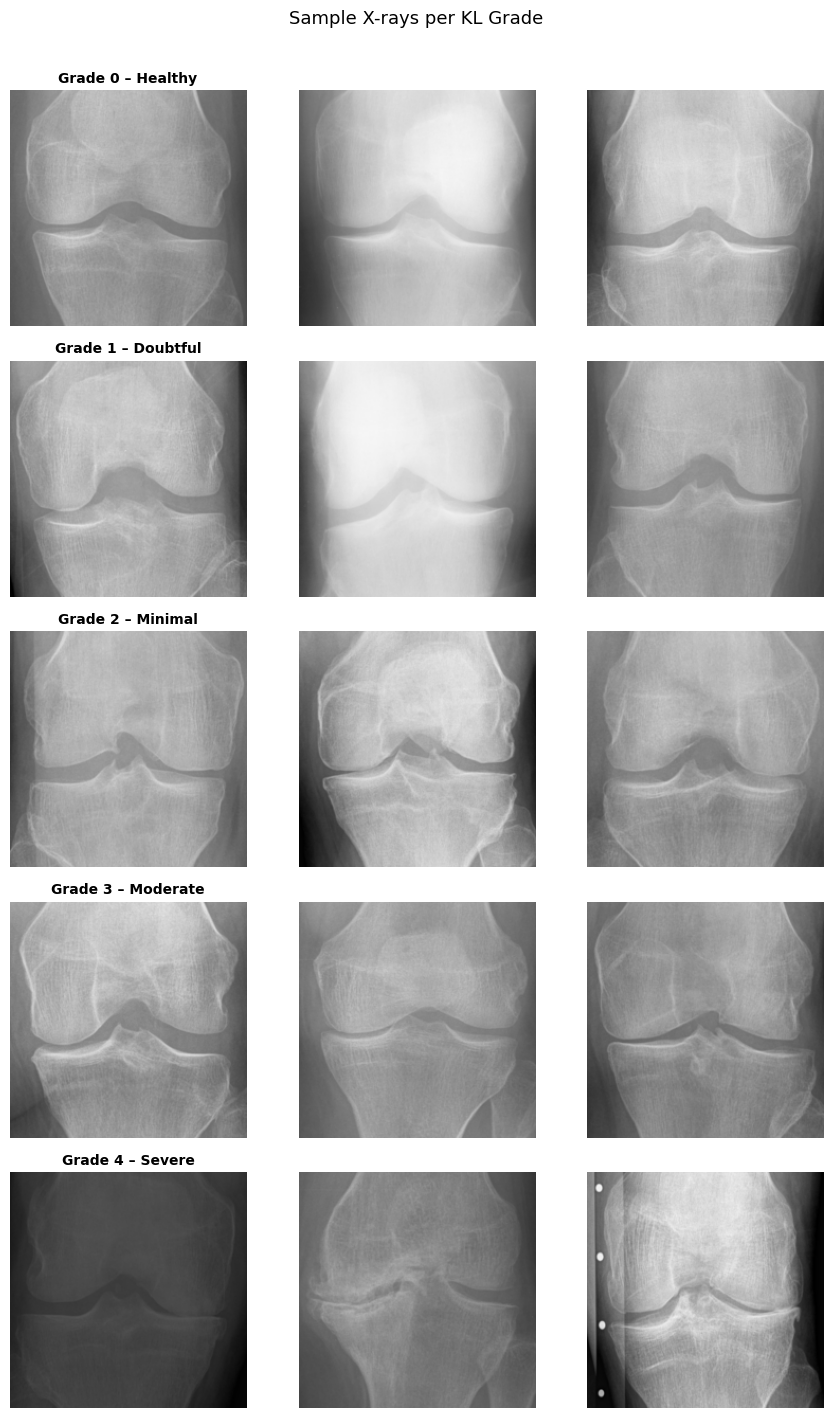

In [6]:
# Sample images – 3 per grade from training set
from PIL import Image

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, 14))
for g in range(NUM_CLASSES):
    imgs = sorted((TRAIN_DIR / str(g)).glob('*.png'))
    samples = random.sample(imgs, min(3, len(imgs)))
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        axes[g, col].imshow(img, cmap='gray')
        axes[g, col].axis('off')
        if col == 0:
            axes[g, col].set_title(f'Grade {g} – {GRADE_LABELS[g]}', fontsize=10, fontweight='bold')
plt.suptitle('Sample X-rays per KL Grade', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Data Augmentation & DataLoaders

**Strategy**:
- **Train**: Random horizontal flip, rotation (±10°), colour jitter, normalise (ImageNet stats)
- **Val / Test**: Resize, centre crop, normalise only

Aggressive augmentation is avoided because X-ray orientation has clinical meaning.

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    # Slight spatial jitter — simulates variation in patient positioning
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # X-ray specific: random auto-contrast and sharpness enhance subtle bone texture
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Class-to-index mapping: {train_dataset.class_to_idx}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


Train: 5778 | Val: 826 | Test: 1656
Class-to-index mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [8]:
# Compute class weights to handle imbalance (inverse-frequency weighting)
train_counts = np.array(counts['train'], dtype=float)
class_weights = torch.tensor(
    (train_counts.sum() / (NUM_CLASSES * train_counts)).astype(np.float32)
).to(DEVICE)

print('Class weights (higher = rarer class gets more penalty):')
for g, w in enumerate(class_weights.cpu().numpy()):
    print(f'  Grade {g} ({GRADE_LABELS[g]}): {w:.3f}')

Class weights (higher = rarer class gets more penalty):
  Grade 0 (Healthy): 0.506
  Grade 1 (Doubtful): 1.105
  Grade 2 (Minimal): 0.762
  Grade 3 (Moderate): 1.527
  Grade 4 (Severe): 6.680


## 6. Model – EfficientNet-B4 (Transfer Learning)

EfficientNet-B4 is chosen over B3 to address underfitting:
- **~19M parameters** vs B3's ~12M — more capacity for subtle KL-grade texture differences
- **380px native resolution** vs 300px — captures finer joint space narrowing detail
- Strong ImageNet pretraining with compound scaling preserved
- Same API as B3 — minimal code change

**Underfitting fix**: Dropout reduced (0.2→0.1 head, 0.1→0.05 pre-classifier) — less regularisation gives the larger model room to learn.

**Fine-tuning strategy**: Freeze backbone → train classifier head for 2 epochs → unfreeze all layers → train end-to-end with lower LR + warmup.


In [ ]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    # Dropout reduced vs B3 (0.2→0.1, 0.1→0.05) — model is underfitting so we need
    # less regularisation, not more. BatchNorm1d still stabilises after unfreezing.
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.1),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(p=0.05),
        nn.Linear(512, num_classes),
    )
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')


Trainable parameters: 789,509 / 11,485,741 (6.9%)


## 7. Training

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, num_epochs, lr, warmup_epochs=0):
    # label_smoothing=LABEL_SMOOTH: treats adjacent KL grades as partially correct
    # (grade 2 predicted as 1 is less wrong than grade 2 predicted as 4)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=WEIGHT_DECAY)

    # LR schedule: optional linear warmup → cosine annealing
    # Warmup prevents large LR destabilising a freshly unfrozen backbone
    if warmup_epochs > 0 and warmup_epochs < num_epochs:
        warmup   = optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
        cosine   = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs - warmup_epochs)
        scheduler = optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])
    else:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0   # save checkpoint on val accuracy, not val loss
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch:>3}/{num_epochs} | '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f} | LR: {current_lr:.2e}')

        # Checkpoint on best val accuracy (directly optimises what we measure)
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_DIR / 'best_efficientnet_b4.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
                break

    return history


In [11]:
# Phase 1: Train classifier head only (frozen backbone)
# Reduced from 5 → 2 epochs to unfreeze backbone sooner (high-bias fix)
print('=== Phase 1: Training classifier head (backbone frozen) ===')
history_phase1 = run_training(model, train_loader, val_loader, num_epochs=2, lr=LR)

=== Phase 1: Training classifier head (backbone frozen) ===
Epoch   1/2 | Train Loss: 1.5239  Acc: 0.3036 | Val Loss: 1.3699  Acc: 0.3511
Epoch   2/2 | Train Loss: 1.4113  Acc: 0.3697 | Val Loss: 1.3430  Acc: 0.4225


In [ ]:
# Phase 2: Unfreeze all layers and fine-tune end-to-end with lower LR + warmup
print('=== Phase 2: Fine-tuning entire network ===')
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

# warmup_epochs=WARMUP_EPOCHS: LR ramps from LR/10 to LR over 5 epochs
# before cosine decay — stabilises gradients through all ~12M parameters
history_phase2 = run_training(
    model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR / 10, warmup_epochs=WARMUP_EPOCHS,
)


=== Phase 2: Fine-tuning entire network ===
Trainable parameters: 11,485,741
Epoch   1/50 | Train Loss: 1.2804  Acc: 0.4057 | Val Loss: 1.1736  Acc: 0.4867
Epoch   2/50 | Train Loss: 1.1526  Acc: 0.4682 | Val Loss: 1.1033  Acc: 0.5145
Epoch   3/50 | Train Loss: 1.0473  Acc: 0.5157 | Val Loss: 1.0516  Acc: 0.5339
Epoch   4/50 | Train Loss: 0.9783  Acc: 0.5268 | Val Loss: 1.0047  Acc: 0.5702
Epoch   5/50 | Train Loss: 0.9049  Acc: 0.5604 | Val Loss: 0.9850  Acc: 0.5702
Epoch   6/50 | Train Loss: 0.8818  Acc: 0.5720 | Val Loss: 0.9378  Acc: 0.5956
Epoch   7/50 | Train Loss: 0.8473  Acc: 0.5682 | Val Loss: 0.9417  Acc: 0.6041
Epoch   8/50 | Train Loss: 0.8237  Acc: 0.5924 | Val Loss: 0.9216  Acc: 0.6017
Epoch   9/50 | Train Loss: 0.7911  Acc: 0.5988 | Val Loss: 0.9160  Acc: 0.6005
Epoch  10/50 | Train Loss: 0.7780  Acc: 0.5957 | Val Loss: 0.9019  Acc: 0.6090
Epoch  11/50 | Train Loss: 0.7658  Acc: 0.6096 | Val Loss: 0.8885  Acc: 0.5920
Epoch  12/50 | Train Loss: 0.7511  Acc: 0.6144 | Val L

## 8. Learning Curves

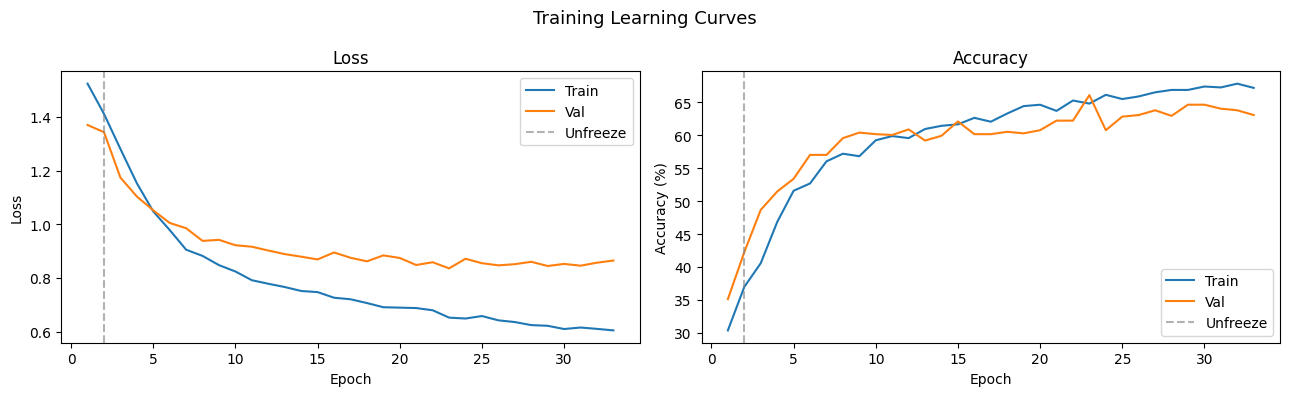

In [13]:
# Merge phase histories
def merge_histories(*histories):
    merged = {k: [] for k in histories[0]}
    for h in histories:
        for k in merged:
            merged[k].extend(h[k])
    return merged

history = merge_histories(history_phase1, history_phase2)
phase1_len = len(history_phase1['train_loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
ax1.legend()

ax2.plot(epochs, [a * 100 for a in history['train_acc']], label='Train')
ax2.plot(epochs, [a * 100 for a in history['val_acc']],   label='Val')
ax2.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Accuracy')
ax2.legend()

plt.suptitle('Training Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 8b. Bias–Variance Diagnostic

| Signal | Interpretation | Fix |
|---|---|---|
| Train acc low, small train–val gap | **High bias** (underfitting) | Bigger model, fewer regularisers, more epochs |
| Train acc high, large train–val gap | **High variance** (overfitting) | More data/augmentation, dropout, weight decay, early stopping |
| Both high | Balanced — check absolute performance |

In [ ]:
# ── Load history from a saved checkpoint (skip training cells) ────────────────
# Run this cell instead of the training cells (Sections 6–8) to diagnose a
# previously saved model.

import torch
from pathlib import Path

MODEL_DIR = Path('models')
CHECKPOINT_PATH = MODEL_DIR / 'knee_kl_efficientnet_b4_final.pth'

ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')

history   = ckpt['history']
phase1_len = ckpt.get('phase1_len', None)   # None if saved before this field was added

print(f'Checkpoint loaded from: {CHECKPOINT_PATH}')
print(f'Test accuracy (saved) : {ckpt["test_accuracy"]*100:.2f}%')
print(f'Total epochs in history: {len(history["train_loss"])}')
print(f'Phase 1 length: {phase1_len}')


Checkpoint loaded from: models/knee_kl_efficientnet_b3_final.pth
Test accuracy (saved) : 60.75%
Total epochs in history: 35
Phase 1 length: None


Using history from current training session.
  BIAS–VARIANCE DIAGNOSTIC
  Final train accuracy : 56.58%
  Final val   accuracy : 58.23%
  Accuracy gap (train–val) : -1.66 pp
  Final train loss : 0.8536
  Final val   loss : 0.9613
  Loss gap (val–train)     : +0.1076
------------------------------------------------------------

  Verdict: 📉 HIGH BIAS  (underfitting)

  → Train for more epochs (increase NUM_EPOCHS)
  → Unfreeze backbone earlier or use a larger model (e.g. EfficientNet-B4/B5)
  → Reduce dropout rates (currently 0.4 / 0.3)
  → Increase learning rate or use a warmer scheduler


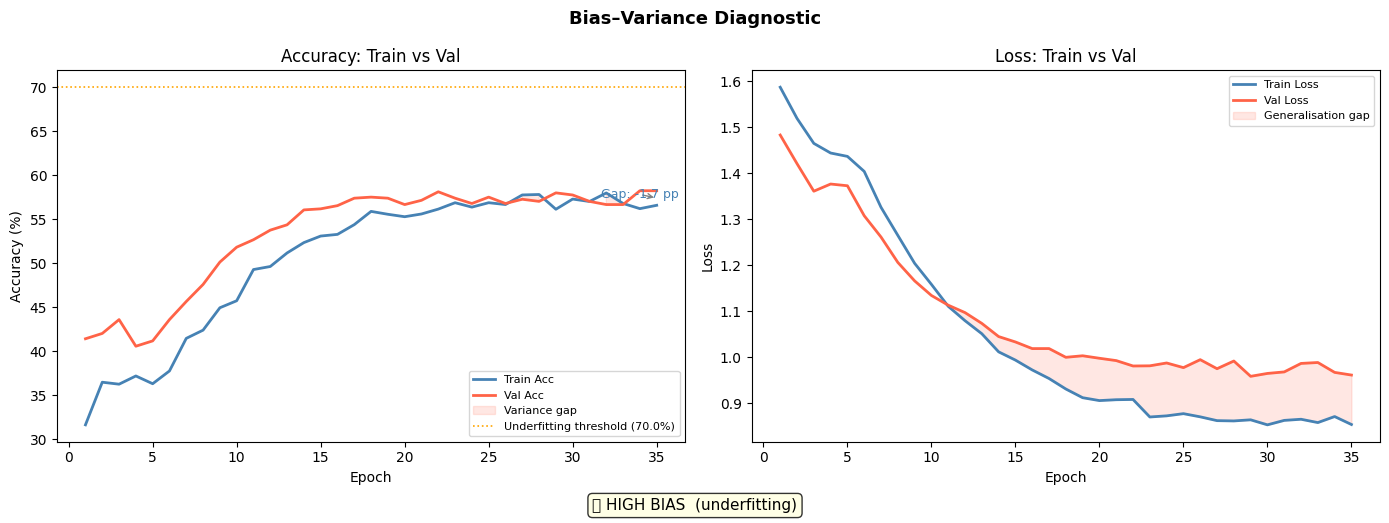

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Auto-load from checkpoint if not already in memory ───────────────────────
if 'history' not in dir() or history is None:
    MODEL_DIR = Path('models')
    CHECKPOINT_PATH = MODEL_DIR / 'knee_kl_efficientnet_b4_final.pth'
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            f'No checkpoint found at {CHECKPOINT_PATH}.\n'
            'Either run the training cells first, or copy the .pth file to the models/ folder.'
        )
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
    history    = ckpt['history']
    phase1_len = ckpt.get('phase1_len', None)
    print(f'Loaded history from checkpoint: {CHECKPOINT_PATH}')
    print(f'Saved test accuracy: {ckpt["test_accuracy"]*100:.2f}%')
else:
    print('Using history from current training session.')

# ── 1. Final-epoch metrics ────────────────────────────────────────────────────
final_train_acc  = history['train_acc'][-1]  * 100
final_val_acc    = history['val_acc'][-1]    * 100
final_train_loss = history['train_loss'][-1]
final_val_loss   = history['val_loss'][-1]

acc_gap  = final_train_acc - final_val_acc     # positive = train > val
loss_gap = final_val_loss  - final_train_loss  # positive = val > train (overfitting)

# ── 2. Thresholds (adjust to your baseline expectations) ─────────────────────
UNDERFITTING_THRESHOLD_ACC = 70.0   # if train acc < this → high bias
OVERFITTING_THRESHOLD_GAP  = 10.0   # if train-val acc gap > this → high variance

print('=' * 60)
print('  BIAS–VARIANCE DIAGNOSTIC')
print('=' * 60)
print(f'  Final train accuracy : {final_train_acc:.2f}%')
print(f'  Final val   accuracy : {final_val_acc:.2f}%')
print(f'  Accuracy gap (train–val) : {acc_gap:+.2f} pp')
print(f'  Final train loss : {final_train_loss:.4f}')
print(f'  Final val   loss : {final_val_loss:.4f}')
print(f'  Loss gap (val–train)     : {loss_gap:+.4f}')
print('-' * 60)

high_bias     = final_train_acc < UNDERFITTING_THRESHOLD_ACC
high_variance = acc_gap > OVERFITTING_THRESHOLD_GAP

if high_bias and high_variance:
    verdict = '⚠  HIGH BIAS + HIGH VARIANCE  (poor fit on all fronts)'
    suggestions = [
        '→ Check data quality and label correctness',
        '→ Try a more powerful architecture or longer training',
        '→ Reduce regularisation strength first, then address variance',
    ]
elif high_bias:
    verdict = '📉 HIGH BIAS  (underfitting)'
    suggestions = [
        '→ Train for more epochs (increase NUM_EPOCHS)',
        '→ Consider EfficientNet-B5 or a ViT-based model',
        '→ Further reduce dropout rates',
        '→ Increase learning rate or use a warmer scheduler',
    ]
elif high_variance:
    verdict = '📈 HIGH VARIANCE  (overfitting)'
    suggestions = [
        '→ Add more aggressive augmentation (e.g. MixUp, CutOut)',
        '→ Increase dropout (try 0.3 / 0.2)',
        '→ Increase weight_decay',
        '→ Collect or synthesise more training data',
        '→ Use stronger early stopping (reduce PATIENCE)',
    ]
else:
    verdict = '✅ BALANCED FIT  (low bias, low variance)'
    suggestions = ['→ Model generalises well. Focus on absolute accuracy now.']

print(f'\n  Verdict: {verdict}')
print()
for s in suggestions:
    print(f'  {s}')
print('=' * 60)

# ── 3. Annotated learning curves ─────────────────────────────────────────────
epochs     = range(1, len(history['train_acc']) + 1)
train_accs = [a * 100 for a in history['train_acc']]
val_accs   = [a * 100 for a in history['val_acc']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bias–Variance Diagnostic', fontsize=13, fontweight='bold')

# Accuracy subplot
ax1.plot(epochs, train_accs, label='Train Acc', color='steelblue', linewidth=2)
ax1.plot(epochs, val_accs,   label='Val Acc',   color='tomato',    linewidth=2)
ax1.fill_between(epochs, val_accs, train_accs,
                 where=[t >= v for t, v in zip(train_accs, val_accs)],
                 alpha=0.15, color='tomato', label='Variance gap')
ax1.axhline(UNDERFITTING_THRESHOLD_ACC, color='orange', linestyle=':', linewidth=1.2,
            label=f'Underfitting threshold ({UNDERFITTING_THRESHOLD_ACC}%)')
if phase1_len:
    ax1.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy: Train vs Val')
ax1.legend(fontsize=8)
ax1.annotate(
    f'Gap: {acc_gap:+.1f} pp',
    xy=(list(epochs)[-1], (final_train_acc + final_val_acc) / 2),
    xytext=(-40, 0), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='tomato' if high_variance else 'steelblue',
)

# Loss subplot
ax2.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax2.fill_between(epochs, history['train_loss'], history['val_loss'],
                 where=[v >= t for t, v in zip(history['train_loss'], history['val_loss'])],
                 alpha=0.15, color='tomato', label='Generalisation gap')
if phase1_len:
    ax2.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss: Train vs Val')
ax2.legend(fontsize=8)

props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
fig.text(0.5, -0.02, verdict, ha='center', fontsize=11, bbox=props)
plt.tight_layout()
plt.show()


## 9. Evaluation on Test Set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_DIR / 'best_efficientnet_b4.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')


Test Accuracy: 0.6546 (65.46%)


In [17]:
# Classification report
print(classification_report(
    all_labels, all_preds,
    target_names=[f'Grade {g} ({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)]
))

                    precision    recall  f1-score   support

 Grade 0 (Healthy)       0.72      0.84      0.78       639
Grade 1 (Doubtful)       0.31      0.25      0.27       296
 Grade 2 (Minimal)       0.65      0.56      0.60       447
Grade 3 (Moderate)       0.76      0.82      0.79       223
  Grade 4 (Severe)       0.77      0.90      0.83        51

          accuracy                           0.65      1656
         macro avg       0.64      0.67      0.65      1656
      weighted avg       0.64      0.65      0.64      1656



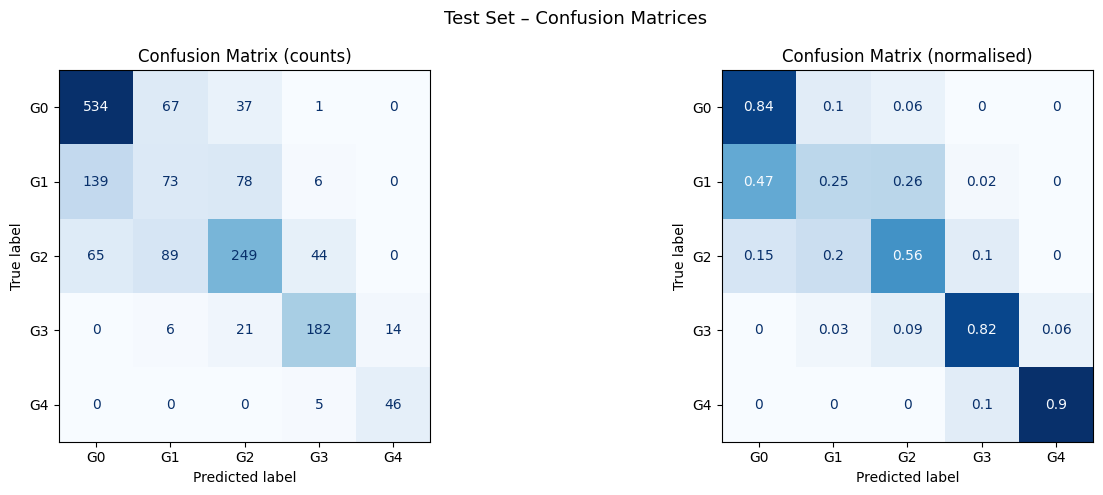

In [18]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'G{g}' for g in range(NUM_CLASSES)])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix (counts)')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2),
                                    display_labels=[f'G{g}' for g in range(NUM_CLASSES)])
disp_norm.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix (normalised)')

plt.suptitle('Test Set – Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

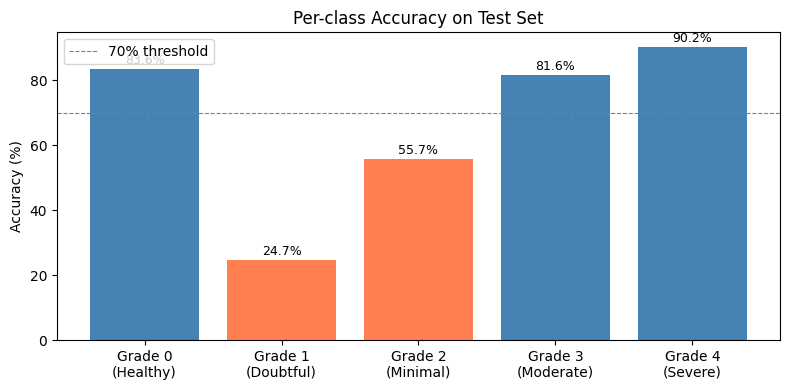

In [19]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f'Grade {g}\n({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)],
    per_class_acc * 100,
    color=['steelblue' if a >= 0.7 else 'coral' for a in per_class_acc]
)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class Accuracy on Test Set')
ax.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='70% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 9b. Test Time Augmentation (TTA)

Run each test image through **5 augmented views** and average the softmax probabilities.
TTA is a zero-cost inference trick that consistently improves accuracy by 1–3 pp on medical imaging tasks.


In [ ]:
@torch.no_grad()
def evaluate_tta(model, dataset, n_augments=5):
    """
    Test Time Augmentation: each image is forward-passed n_augments times
    with random augmentations; the averaged softmax is used for the final prediction.
    """
    tta_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])

    model.eval()
    all_preds_tta, all_labels_tta = [], []

    for idx in range(len(dataset)):
        raw_img, label = dataset.imgs[idx]
        from PIL import Image as _PIL_Image
        pil_img = _PIL_Image.open(raw_img).convert('RGB')

        # Average logits over n_augments views
        prob_sum = None
        for _ in range(n_augments):
            tensor = tta_transforms(pil_img).unsqueeze(0).to(DEVICE)
            logits = model(tensor)
            probs  = torch.softmax(logits, dim=1).squeeze(0)
            prob_sum = probs if prob_sum is None else prob_sum + probs

        pred = (prob_sum / n_augments).argmax().item()
        all_preds_tta.append(pred)
        all_labels_tta.append(label)

    all_preds_tta  = np.array(all_preds_tta)
    all_labels_tta = np.array(all_labels_tta)
    return all_preds_tta, all_labels_tta


print(f'Running TTA with 5 augmented views per image on {len(test_dataset)} test images...')
tta_preds, tta_labels = evaluate_tta(model, test_dataset, n_augments=5)

tta_acc = (tta_preds == tta_labels).mean()
print(f'\nStandard test accuracy : {test_acc*100:.2f}%')
print(f'TTA test accuracy      : {tta_acc*100:.2f}%')
print(f'TTA improvement        : {(tta_acc - test_acc)*100:+.2f} pp')

print('\nTTA Classification Report:')
print(classification_report(
    tta_labels, tta_preds,
    target_names=[f'Grade {g} ({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)]
))


## 10. Save Model & Artefacts

In [ ]:
# Save full model checkpoint with metadata
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': 'efficientnet_b4',
    'test_accuracy': float(test_acc),
    'history': history,
    'phase1_len': phase1_len,
}
save_path = MODEL_DIR / 'knee_kl_efficientnet_b4_final.pth'
torch.save(checkpoint, save_path)
print(f'Model saved to: {save_path}')


Model saved to: models/knee_kl_efficientnet_b3_final.pth


## 11. Inference – Single Image

Helper function to predict the KL grade for a single X-ray image.

Image     : 9292027L.png
True grade: 0 (Healthy)
Predicted : 0 (Healthy)  confidence: 66.77%

Probabilities:
  Grade 0: ██████████████████████████ 66.77%
  Grade 1: █████████ 22.60%
  Grade 2: ███ 9.00%
  Grade 3:  1.16%
  Grade 4:  0.48%


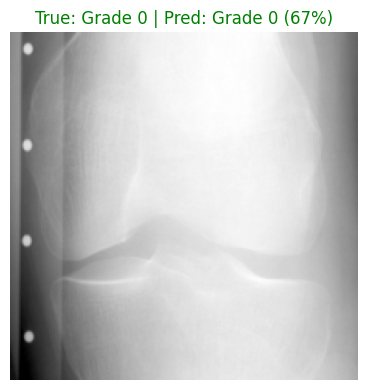

In [21]:
from PIL import Image

def predict_single(image_path: str, model: nn.Module) -> dict:
    img = Image.open(image_path).convert('RGB')
    tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = int(probs.argmax())
    return {
        'predicted_grade': pred,
        'label': GRADE_LABELS[pred],
        'confidence': float(probs[pred]),
        'probabilities': {f'Grade {g}': float(p) for g, p in enumerate(probs)},
    }


# Example: run on a random test image
sample_paths = list(TEST_DIR.rglob('*.png'))
sample = random.choice(sample_paths)
true_grade = int(sample.parent.name)

result = predict_single(sample, model)
print(f'Image     : {sample.name}')
print(f'True grade: {true_grade} ({GRADE_LABELS[true_grade]})')
print(f'Predicted : {result["predicted_grade"]} ({result["label"]})  confidence: {result["confidence"]:.2%}')
print('\nProbabilities:')
for k, v in result['probabilities'].items():
    bar = '█' * int(v * 40)
    print(f'  {k}: {bar} {v:.2%}')

# Display the image
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(sample), cmap='gray')
colour = 'green' if result['predicted_grade'] == true_grade else 'red'
ax.set_title(f'True: Grade {true_grade} | Pred: Grade {result["predicted_grade"]} ({result["confidence"]:.0%})',
             color=colour)
ax.axis('off')
plt.tight_layout()
plt.show()